# OLS Regression: Einkommen vorhersagen (`ConvertedTotalComp`)


In [1]:
import pandas as pd
import numpy as np

import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [2]:

df = pd.read_csv("One-Hot-Encoded.csv")


q98 = df["ConvertedCompTotal"].dropna().quantile(0.98)
df = df[df["ConvertedCompTotal"] <= q98].copy()
print(df["ConvertedCompTotal"].describe())

bool_cols = df.select_dtypes(include=['bool']).columns

for col in bool_cols:
    df[col] = df[col].astype(int)
df.dtypes

count     21785.000000
mean      86982.492836
std       63772.008524
min           0.000000
25%       40873.000000
50%       75924.190383
75%      120000.000000
max      331000.000000
Name: ConvertedCompTotal, dtype: float64


MaxAge                                                            float64
AgeNum                                                            float64
WorkExp                                                           float64
YearsCode                                                         float64
RemoteCategoryNum                                                 float64
                                                                   ...   
AIAgents_no, i use ai exclusively in copilot/autocomplete mode      int64
AIAgents_yes, i use ai agents at work daily                         int64
AIAgents_yes, i use ai agents at work monthly or infrequently       int64
AIAgents_yes, i use ai agents at work weekly                        int64
AIAgents_nan                                                        int64
Length: 484, dtype: object

In [ ]:
TARGET = "ConvertedCompTotal"

num_cols = df.select_dtypes(include=["number"]).columns.tolist()
feature_cols = [c for c in num_cols if c != TARGET]

X = df[feature_cols].copy()
y = df[TARGET].copy()
X = X.drop(columns=["ConvertedCompYearly"])


# Konsistentes Dropna (X vollständig + y vorhanden)
mask = X.notna().all(axis=1) & y.notna()
X = X.loc[mask].copy()
y = y.loc[mask].copy()

print("After dropna -> X:", X.shape, "y:", y.shape)
y.describe()

After dropna -> X: (15428, 467) y: (15428,)


count     15428.000000
mean      91800.239447
std       62085.501875
min           0.000000
25%       47969.373211
50%       81746.000000
75%      125000.000000
max      331000.000000
Name: ConvertedCompTotal, dtype: float64

In [7]:
y_model = y.astype(float)

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_model,
    test_size=0.2,
    random_state=42
)

y_train_log = np.log1p(y_train)
y_test_log  = np.log1p(y_test)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (12342, 467) Test: (3086, 467)


In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

num_cols = ["MaxAge", "AgeNum", "WorkExp", "YearsCode", "RemoteCategoryNum"]
dummy_cols = [c for c in X.columns if c not in num_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("dum", "passthrough", dummy_cols),
    ],
    remainder="drop"
)


In [ ]:

scaler = StandardScaler()
X_train_sc = preprocess.fit_transform(X_train)
X_test_sc  = preprocess.transform(X_test)

# Intercept hinzufügen
X_train_sc_const = sm.add_constant(X_train_sc, has_constant="add")
X_test_sc_const  = sm.add_constant(X_test_sc, has_constant="add")

X_train_sc_const.shape, X_test_sc_const.shape

((12342, 468), (3086, 468))

In [10]:
# OLS fitten
ols = sm.OLS(np.asarray(y_train_log, dtype=float), X_train_sc_const)
results = ols.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.397
Model:                            OLS   Adj. R-squared:                  0.384
Method:                 Least Squares   F-statistic:                     29.99
Date:                Sun, 21 Dec 2025   Prob (F-statistic):               0.00
Time:                        19:16:12   Log-Likelihood:                -18531.
No. Observations:               12342   AIC:                         3.759e+04
Df Residuals:                   12076   BIC:                         3.957e+04
Df Model:                         265                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.5349      0.037     41.352      0.0

In [11]:
# Vorhersage auf log-Skala
y_pred_log = results.predict(X_test_sc_const)

# Rücktransformieren in Originaleinheiten
y_pred = np.expm1(y_pred_log)

# Metriken auf Original-Skala
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("Test R²:", r2)
print("Test RMSE:", rmse)
print("Test MAE:", mae)


Test R²: 0.49741741411017937
Test RMSE: 43479.00165650832
Test MAE: 29111.66843039597


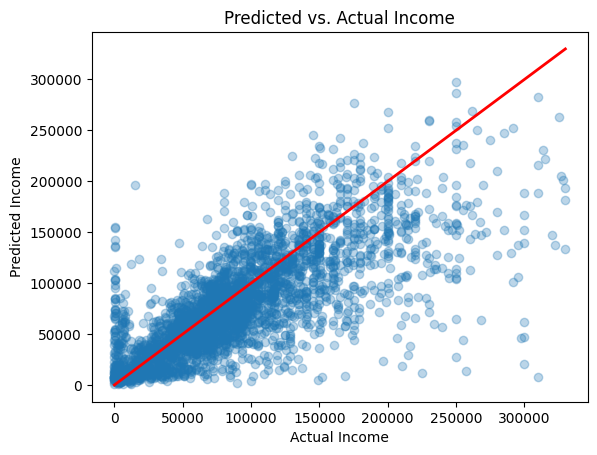

In [12]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red", linewidth=2
)
plt.xlabel("Actual Income")
plt.ylabel("Predicted Income")
plt.title("Predicted vs. Actual Income")
plt.show()



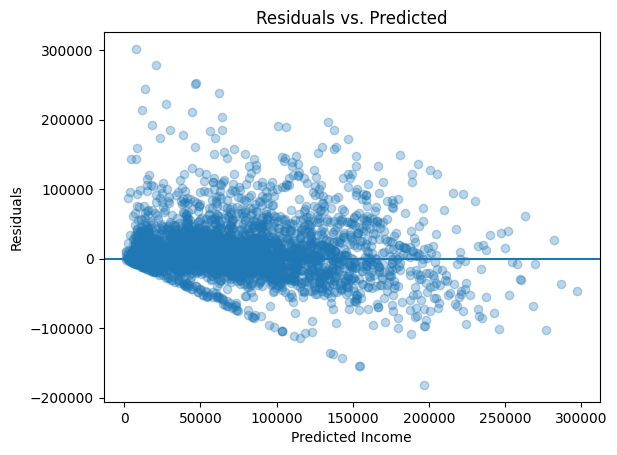

In [13]:
residuals = y_test - y_pred

plt.figure()
plt.scatter(y_pred, residuals, alpha=0.3)
plt.axhline(0)
plt.xlabel("Predicted Income")
plt.ylabel("Residuals")
plt.title("Residuals vs. Predicted")
plt.show()


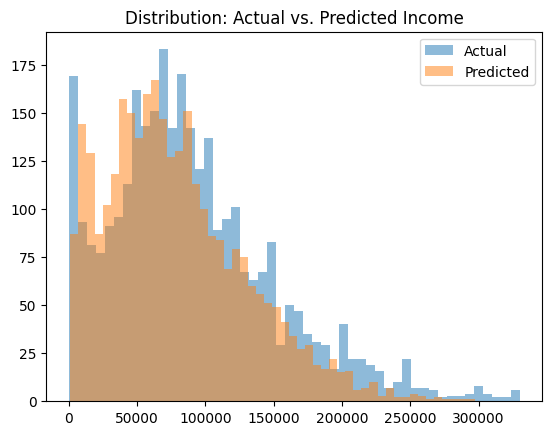

In [14]:
plt.figure()
plt.hist(y_test, bins=50, alpha=0.5, label="Actual")
plt.hist(y_pred, bins=50, alpha=0.5, label="Predicted")
plt.legend()
plt.title("Distribution: Actual vs. Predicted Income")
plt.show()
